# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [120]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

# split: train_df, valid_df를 8:2 비율로, churn 컬럼을 기준으로 고르게 쪼갬
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=df['churn'])

# pycaret분류 import
from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn", # 타겟변수를 churn으로 설정
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0600
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.1280
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.1400
catboost,CatBoost Classifier,0.8584,0.8641,0.4637,0.7472,0.5708,0.4918,0.5126,1.1520
rf,Random Forest Classifier,0.8582,0.8443,0.4436,0.7601,0.5593,0.4820,0.5072,0.0940
xgboost,Extreme Gradient Boosting,0.8441,0.8396,0.4786,0.6645,0.5555,0.4641,0.4738,0.0410
et,Extra Trees Classifier,0.8532,0.8424,0.4269,0.7459,0.5418,0.4622,0.4883,0.1010
dt,Decision Tree Classifier,0.7862,0.6777,0.4943,0.4769,0.4849,0.3502,0.3507,0.0130
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0090
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0090


In [121]:
# 인코딩 전 데이터 살펴보기
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')
df.head(5) # 5개만 뽑아서 확인
# country, gender는 범주형으로 인코딩 필요함

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [122]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)

# 데이터 전처리
# 1) 결측치 확인
df.info() # 확인결과, 결측치 존재하지 않음

# 2) 데이터 타입 확인 (5개만 뽑아봄)
df.head(5)
# customer_id는 고객 고유 식별 번호라 컬럼에서 제외함
df = df.drop(columns=['customer_id'], errors='ignore')
# country, gender는 범주형으로 인코딩 필요함
le_country = LabelEncoder()
le_gender = LabelEncoder()
df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])
# 전처리가 잘되었는지 확인 (5개만 뽑아봄)
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


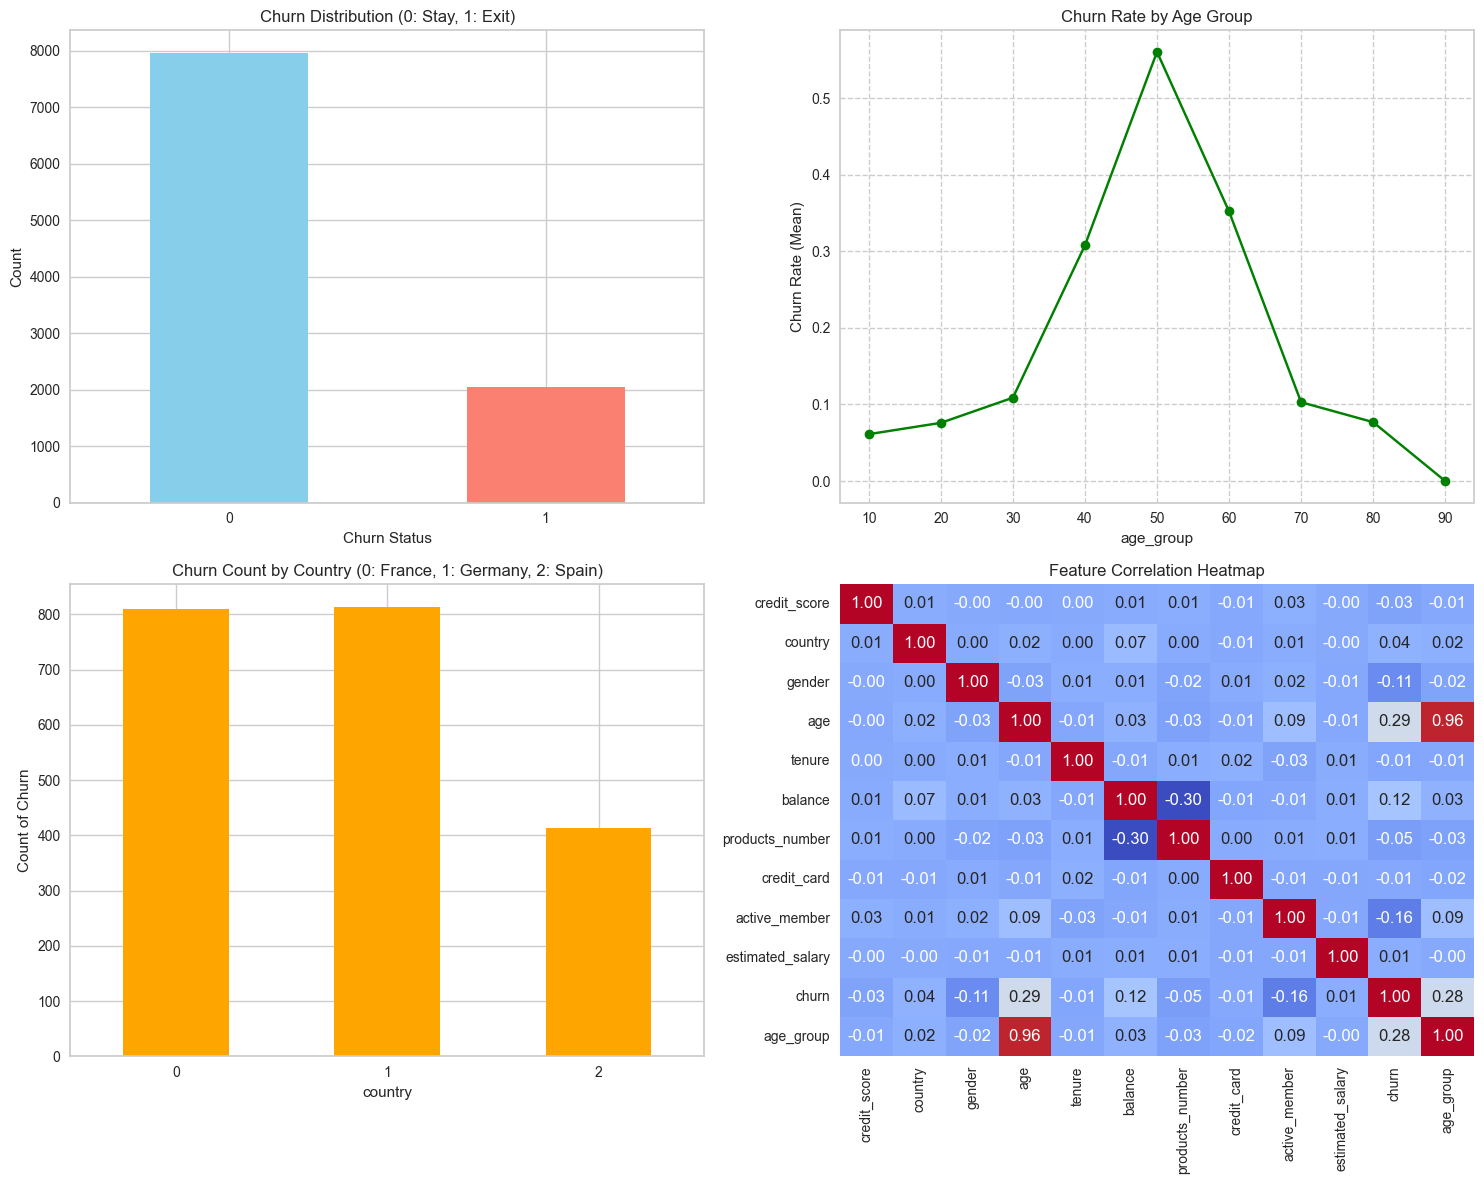

In [123]:
# 시각화를 위해 import
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 size 지정함
plt.figure(figsize=(15, 12))

# 1번 그래프: 이탈 여부 분포 (Bar)
# 얼마나 많은 사람들이 이탈했는가를 살펴봄 (0: 유지, 1: 이탈)
# 이탈보다는 유지의 비율이 훨씬 많음을 알 수 있음
plt.subplot(2, 2, 1) # 2*2로 분할한 그래프의 첫번째 칸으로 지정
df['churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon']) # churn값을 세어서, bar 그래프로 표현해봄
plt.title('Churn Distribution (0: Stay, 1: Exit)') # 그래프 제목 설정
plt.xlabel('Churn Status') # 그래프 x축 라벨 설정
plt.ylabel('Count') # 그래프 y축 라벨 설정
plt.xticks(rotation=0) # x축 범주명 회전각도 설정

# 2번 그래프: 나이대별 평균 이탈률 (Line)
# 이탈률이 30대부터 급격하게 증가하기 시작하다가, 50대에서 이탈률 정점을 찍고
# 그 이후로 70대까지 급격하게 감소했다가 서서히 이탈률이 줄어드는 양상을 보임
# 이탈률이 가장 높은 50대를 위한 상품 제안이 필요해 보임
plt.subplot(2, 2, 2) # 2*2로 분할한 그래프의 두번째 칸으로 지정
df['age_group'] = (df['age'] // 10) * 10 # age를 나이대로 표현하기 위해서 10을 기준으로 쪼개서 age_group이라는 변수에 저장
df.groupby('age_group')['churn'].mean().plot(kind='line', marker='o', color='green')
# age_group에 따른 이탈률 평균을 선그래프로 나타냄
plt.title('Churn Rate by Age Group') # 그래프 제목지정
plt.ylabel('Churn Rate (Mean)') # 그래프 y축 라벨 설정
plt.grid(True, linestyle='--') # 그리드 표현

# 3번 그래프: 국가별 이탈자 합계 (Bar)
# le_country.classes_로 인코딩된 국가 순서 확인, (0: France, 1: Germany, 2: Spain)
# Spain이 이탈자가 France, Germany에 비해 적음.
# Spain에서 왜 이탈자가 작은지 분석해보고, 타국에도 적용가능하다면 적용 고려.
plt.subplot(2, 2, 3) # 2*2로 분할한 그래프의 세번째 칸으로 지정
df.groupby('country')['churn'].sum().plot(kind='bar', color='orange') # 국가별 이탈여부 합을 바 그래프로 나타냄
plt.title('Churn Count by Country (0: France, 1: Germany, 2: Spain)') # 그래프 제목 설정
plt.ylabel('Count of Churn') # 그래프 y축 라벨 설정
plt.xticks(rotation=0) # x축 범주명 회전각도 설정

# 4번 그래프: 상관관계 히트맵 (Heatmap)
# 수치형 데이터들 간의 상관관계 시각화
# -0.25 ~ +0.25 사이의 값은 상관관계가 약하다고 봄.
# 따라서 -0.25보다 작거나, +0.25보다 큰 값이 나온 부분을 중점으로 살펴볼 필요가 있음
plt.subplot(2, 2, 4) # 2*2로 분할한 그래프의 네번째 칸으로 지정
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
# 히트맵으로 수치형 데이터들 간의 상관관계를 그려봄
plt.title('Feature Correlation Heatmap') # 그래프 제목지정

plt.tight_layout() # 그래프 간의 간격 자동 조정
plt.show() # 그래프 출력

In [124]:
# 이탈률을 예측하는 모델을 설정하기 위해서
# y를 정답값인 이탈률(churn)로 지정하고,
# churn을 제외한 컬럼을 X로 지정
# X, y
X = df.drop(columns=['churn', 'age_group']) # 위 EDA 과정에서 만들었던 age_group 컬럼 다시 제거
y = df['churn'] # 타겟 변수인 churn을 y로 지정

# train, valid 값을 8:2의 비율로 쪼갬
# y값을 기준으로 고르게 쪼개줌.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링 진행 (StandardScaler)
scaler = StandardScaler()
# X_train의 값을 스케일링해서 fit 시켜줌
X_train = scaler.fit_transform(X_train)
# X_valid의 값을 스케일링해서 저장함
X_valid = scaler.transform(X_valid)

In [ ]:
# 모델 선정 근거
# 1. 맨 처음에 진행했던 PyCaret을 통해 자동화 머신러닝을 진행하고, F1-Score 값을 기준으로 모델 정렬
# 2. F1-Score의 값을 기준으로 성능이 가장 우수한 상위 4개의 모델을 선정함
# 선정된 모델: (1) Ada Boost Classifier, (2) Light Gradient Boosting Machine, (3) Gradient Boosting Classifier, (4) CatBoost Classifier
# 이는 모두 부스팅 계열로, 이후 스태킹 앙상블을 통해 개별 모델의 한계를 상호 보완하도록 설계.

In [ ]:
# 선정된 모델들을 import 함
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# 모델 학습결과를 평가하기 위한 f1_score, accuracy_score import
from sklearn.metrics import f1_score, accuracy_score

In [127]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기

# 1. Ada Boost Classifier
def objective_ada(trial):
    # 탐색할 하이퍼파라미터 범위 설정
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300), # 학습할 나무 개수 범위 설정 (50~300)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True) # 이전 모델의 오차를 얼마나 강하게 반영할지 결정
    }
    model = AdaBoostClassifier(**params, random_state=42) # 설정된 파라미터로 모델 생성, random_state로 고정
    model.fit(X_train, y_train) # X_train, y_train의 값을 넣어 모델 학습
    return f1_score(y_valid, model.predict(X_valid)) # 학습한 모델에 y_valid, 예측값(X_valid)을 넣어 f1_score 산출

# 2. Light Gradient Boosting Machine (LGBM)
def objective_lgbm(trial):
    # 탐색할 하이퍼파라미터 범위 설정
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500), # 학습할 나무 개수 범위 설정 (100~500)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), # 이전 모델의 오차를 얼마나 강하게 반영할지 결정
        'max_depth': trial.suggest_int('max_depth', 3, 15), # 나무 최대 깊이 범위 설정 (3~15)
        'num_leaves': trial.suggest_int('num_leaves', 2, 256), # 하나의 나무가 가질 수 있는 최대 잎사귀 수 
        'verbose': -1  # 경고 메시지 방지
    }
    model = LGBMClassifier(**params, random_state=42) # 설정된 파라미터로 모델 생성, random_state로 고정
    model.fit(X_train, y_train) # X_train, y_train의 값을 넣어 모델 학습
    return f1_score(y_valid, model.predict(X_valid)) # 학습한 모델에 y_valid, 예측값(X_valid)을 넣어 f1_score 산출


# 3. Gradient Boosting Classifier (GBC)
def objective_gbc(trial):
    # 탐색할 하이퍼파라미터 범위 설정
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300), # 학습할 나무 개수 범위 설정 (50~300)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2), # 이전 모델의 오차를 얼마나 강하게 반영할지 결정
        'max_depth': trial.suggest_int('max_depth', 3, 10) # 나무 최대 깊이 범위 설정 (3~10)
    }
    model = GradientBoostingClassifier(**params, random_state=42) # 설정된 파라미터로 모델 생성, random_state로 고정
    model.fit(X_train, y_train) # X_train, y_train의 값을 넣어 모델 학습
    return f1_score(y_valid, model.predict(X_valid)) # 학습한 모델에 y_valid, 예측값(X_valid)을 넣어 f1_score 산출


# 4. CatBoost Classifier (CB)
def objective_cb(trial):
    # 탐색할 하이퍼파라미터 범위 설정
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500), # CatBoost에서는 n_estimators와 같은 의미로 쓰임 (범위: 100~500)
        'depth': trial.suggest_int('depth', 4, 10), # 깊이는 4~10
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), # 이전 모델의 오차를 얼마나 강하게 반영할지 결정
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10) # L2 정규화 계수
    }
    model = CatBoostClassifier(**params, verbose=0, random_state=42) # 설정된 파라미터로 모델 생성, random_state로 고정
    model.fit(X_train, y_train) # X_train, y_train의 값을 넣어 모델 학습
    return f1_score(y_valid, model.predict(X_valid)) # 학습한 모델에 y_valid, 예측값(X_valid)을 넣어 f1_score 산출


In [ ]:
# 각 모델별 스터디 생성 및 실행
# 위에서 optuna를 통해 찾은 최적의 파라미터를 바탕으로 모델별 스터디를 생성 및 실행함
# direction='maximize': 값의 결과가 최대로 나오도록 지정
# n_trials = 총 10번 돌려보겠다고 지정
study_ada = optuna.create_study(direction='maximize')
study_ada.optimize(objective_ada, n_trials=10)

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=10)

study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=10)

study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective_cb, n_trials=10)

[I 2026-04-09 16:58:15,944] A new study created in memory with name: no-name-8c987ebf-35cc-4ce7-bb45-68d0b8bb3854
[I 2026-04-09 16:58:16,226] Trial 0 finished with value: 0.21739130434782608 and parameters: {'n_estimators': 57, 'learning_rate': 0.06537100712724982}. Best is trial 0 with value: 0.21739130434782608.
[I 2026-04-09 16:58:17,543] Trial 1 finished with value: 0.4912891986062718 and parameters: {'n_estimators': 265, 'learning_rate': 0.03189484684346618}. Best is trial 1 with value: 0.4912891986062718.
[I 2026-04-09 16:58:18,476] Trial 2 finished with value: 0.18625277161862527 and parameters: {'n_estimators': 189, 'learning_rate': 0.014112966470051851}. Best is trial 1 with value: 0.4912891986062718.
[I 2026-04-09 16:58:18,759] Trial 3 finished with value: 0.572289156626506 and parameters: {'n_estimators': 60, 'learning_rate': 0.4812694900904958}. Best is trial 3 with value: 0.572289156626506.
[I 2026-04-09 16:58:19,995] Trial 4 finished with value: 0.5676077265973254 and par

In [ ]:
# 1. 최적화된 하이퍼파라미터로 모델 정의 (random_state로 결과 고정)
# 위에서 총 10번의 시도 끝에 가장 값의 결과가 좋았던 파라미터를
# best_params를 통해 가져와서 모델을 정의함.
ada  = AdaBoostClassifier(**study_ada.best_params, random_state=42)
lgbm = LGBMClassifier(**study_lgbm.best_params, verbose=-1, random_state=42)
gbc  = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
cb   = CatBoostClassifier(**study_cb.best_params, verbose=0, random_state=42)

# 2. 모델 학습
# 각 모델별로 X, y의 학습데이터를 fit해서 학습시킴
ada.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
gbc.fit(X_train, y_train)
cb.fit(X_train, y_train)

# 3. 반복문을 통한 성능 확인 (F1 스코어)
# 모델 이름과 변수를 튜플 형태로 리스트에 담아 반복문을 돌림
models = [
    ('AdaBoost', ada), 
    ('LGBM', lgbm), 
    ('GBC', gbc), 
    ('CatBoost', cb)
]

# 각 모델별로 검증 데이터인 f1_score를 출력해봄
print("각 모델별 검증 데이터 F1 스코어:")
for name, model in models:
    pred = model.predict(X_valid)
    f1 = f1_score(y_valid, pred)
    print(f"{name:10} F1: {f1:.4f}")

각 모델별 검증 데이터 F1 스코어:
AdaBoost   F1: 0.5723
LGBM       F1: 0.5931
GBC        F1: 0.6006
CatBoost   F1: 0.6049


In [130]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)

# 4개 모델을 Stacking (전방모델, 후방모델 아무거나)
# F1_score=57, accuracy_score=80 정도 출력될거임.
# 캐글에 머신러닝 잘하는 사람들거 있음. 

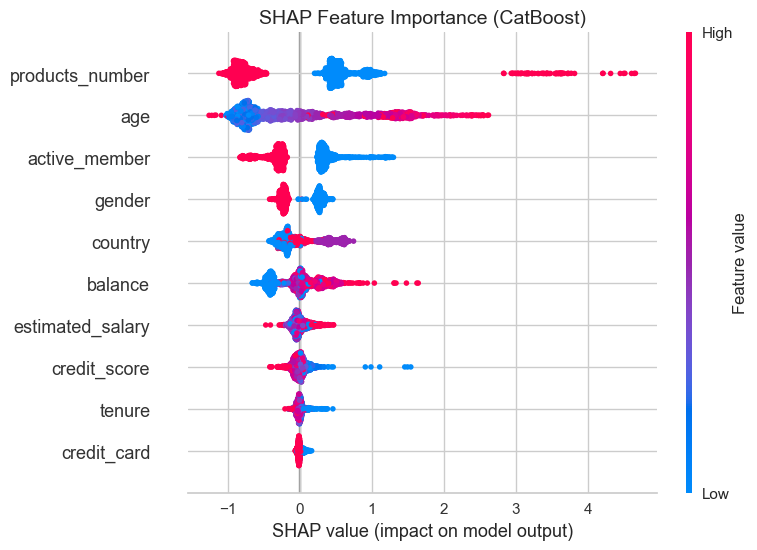

StackingClassifier(cv=5,
                   estimators=[('ada',
                                AdaBoostClassifier(algorithm='SAMME.R',
                                                   estimator=None,
                                                   learning_rate=0.4812694900904958,
                                                   n_estimators=60,
                                                   random_state=42)),
                               ('lgbm',
                                LGBMClassifier(boosting_type='gbdt',
                                               class_weight=None,
                                               colsample_bytree=1.0,
                                               importance_type='split',
                                               learning_rate=0.0737969469081416,
                                               max_depth=13,
                                               min_child_samples=20,
                                               min_child_we...
                                CatBoostClassifier(depth=5, iterations=188, l2_leaf_reg=1.8408148959333295, learning_rate=0.09144954741533008, random_state=42, verbose=0))],
                   final_estimator=LogisticRegression(C=1.0, class_weight=None,
                                                      dual=False,
                                                      fit_intercept=True,
                                                      intercept_scaling=1,
                                                      l1_ratio=None,
                                                      max_iter=100,
                                                      multi_class='auto',
                                                      n_jobs=None, penalty='l2',
                                                      random_state=None,
                                                      solver='lbfgs',
                                                      tol=0.0001, verbose=0,
                                                      warm_start=False),
                   n_jobs=-1, passthrough=False, stack_method='auto',
                   verbose=0)

In [ ]:
# 위에서 돌려본 F1 스코어 중에서 가장 높은 CatBoost를 기준으로 SHAP 사후 분석 진행

# 1. SHAP 사후 분석 (CatBoost 모델 기준)
explainer = shap.TreeExplainer(cb) 
shap_values = explainer.shap_values(X_valid)

# [중요] SHAP 결과값 차원 맞추기 (이진 분류 대응)
# CatBoost는 버전에 따라 리스트나 3차원 배열로 반환될 수 있어 아래 로직이 필수입니다.
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

# SHAP Summary Plot 시각화
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_valid, 
    feature_names=X.columns.tolist(), # 리스트로 변환하여 에러 방지
    plot_type="dot",
    show=False
)
plt.title("SHAP Feature Importance (CatBoost)", fontsize=14)
plt.show()


# 2. 스태킹(Stacking) 모델 합체
# 전방 모델 리스트
est_model_list = [
    ('ada', ada),
    ('lgbm', lgbm),
    ('gbc', gbc),
    ('cb', cb)
]

# Stacking 모델 정의 및 학습
stack = StackingClassifier(
    estimators = est_model_list, # 위에서 설정한 전방모델 리스트를 전방모델로 정의
    final_estimator = LogisticRegression(), # LogisticRegression을 후방모델로 정의
    cv = 5, # 5-Fold 교차 검증을 통해 과적합 방지
    n_jobs = -1 # 컴퓨터의 모든 CPU 사용
)

stack.fit(X_train, y_train) # X, y의 훈련데이터를 stack에 fit해서 학습시킴

In [132]:
# SHAP vlaue 사후분석
# churn은 이탈여부로 타겟 변수임. (0: 유지, 1: 이탈)
# products_number(상품 수): 상품의 수가 특정 임계값을 넘어가면 이탈 가능성이 커지는데,
#                        그 경우를 제외하고는 상품의 수가 많으면 유지에 가깝고, 적으면 이탈에 가까워짐
# age: 나이가 많을수록 이탈가능성이 커지고, 나이가 어릴수록 이탈가능성이 낮음
#     하지만 일부의 경우에는 나이가 많은데 유지하는 경향을 보이기도 함.
# active_member: 활성된 고객은 유지, 비활성된 고객은 이탈
# balance: 계좌 잔액이 많을수록 이탈에 가까움
# gender (0: Female, 1: Male): 여성은 이탈, 남성은 유지에 가까움. 하지만 이탈여부에 미치는 영향은 미미함. (폭이 좁음)
# country (0: France, 1: Germany, 2: Spain): France는 유지, Germany는 이탈에 더 가까움
# estimated_salary: 추정연봉은 빨간점과 파란점이 뚜렷한 양상을 보이지 않기 때문에 판단하기 어려움
# credit_score: 신용도가 낮을 수록 이탈에 조금 더 가까움
# tenure: 이용한 기간이 적을수록 이탈에 가까워지지만 큰 폭의 분포를 띄는 것은 아닌 걸로 보아 영향은 미미함
# credit_card: 분포가 많이 퍼져있지 않고 0에 가까운 것으로 보아 이탈여부에 미치는 영향은 미미함

# 결론적으로 pproducts_number와 age가 가장 넓게 분포되어 있으므로 모델이 이탈 여부를 결정할 때 큰 영향을 미침
# 반면에, country, gender, tenure, credit_card의 경우에는 0에 가깝고, 좁게 분포되어 있는 것으로 보아
# 모델이 이탈 여부를 결정할 때 미치는 영향력이 미미함을 알 수 있음

# 인사이트 제안
# 1. 특정 갯수 이상의 상품수를 이용중인 50대 이상 고객을 위험 고객으로 분류하고, 전담 상담원을 배정하여 자산 관리 서비스 제공
# 2. 활성 유지를 위해, 일정 기간 거래가 없는 고객에게 수수료 면제 또는 알림을 제공하여 활동성을 부여하는 이벤트 실행
# 3. 잔액이 높은 고객들이 이탈하는 경향이 있으므로, 예금 잔액에 비례한 등급제(ex. VIP)를 시행하여 등급에 따른 차등 서비스 제공

In [133]:
# 예측 및 성능 출력
pred = stack.predict(X_valid) # 학습된 모델에 X_valid 값을 넣고 예측값 뽑아내기
print(f"Stacking 최종 F1 Score: {f1_score(y_valid, pred):.4f}") # y_valid와 pred 값을 넣어서 모델의 f1 score 계산
print(f"Stacking 최종 Accuracy: {accuracy_score(y_valid, pred):.4f}") # y_valid와 pred 값을 넣어서 모델의 accuracy score 계산

Stacking 최종 F1 Score: 0.6129
Stacking 최종 Accuracy: 0.8705
